# KTAS Triage Priority Prediction — EDA & Gradient Boosting Model Comparison

**Dataset:** 1267 adult ED patients, systematically selected from two Korean emergency departments between October 2016 and September 2017. Twenty-four variables were recorded per visit, including chief complaint, vital signs from initial nursing assessment, and clinical outcomes. The ground-truth triage level (`KTAS_expert`) was determined by a panel of three triage experts (a certified emergency nurse, a KTAS provider/instructor, and an experienced ED nurse) — independent of the treating nurse's own real-time triage call (`KTAS_RN`).

**Goal:** Predict `KTAS_expert` (1 = most urgent → 5 = least urgent) from information available **at the moment of triage**, so this model can realistically power a nurse-facing decision-support tool — not just score well on paper.

**Notebook sections**
1. Setup
2. Load & clean the raw data
3. Understanding the dataset (column reference)
4. Missing-value analysis
5. Target & feature distributions
6. Correlation analysis
7. ⚠️ Data-leakage audit (critical for a real deployment)
8. Feature engineering
9. Train/test split & class weighting
10. Model 1 — XGBoost
11. Model 2 — CatBoost
12. Model 3 — LightGBM
13. Cost-sensitive triage threshold
14. **Model comparison**
15. Conclusions


## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr

sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.edgecolor'] = '#333333'

# KTAS acuity color scale: 1 (most urgent, red) -> 5 (least urgent, green)
KTAS_PALETTE = {1: "#d62728", 2: "#ff7f0e", 3: "#f4d03f", 4: "#82c785", 5: "#2e8b57"}
KTAS_ORDER = [1, 2, 3, 4, 5]
KTAS_COLORS = [KTAS_PALETTE[k] for k in KTAS_ORDER]

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Uncomment on a fresh Colab runtime:
# !pip install xgboost catboost lightgbm -q

## 2. Load & clean the raw data

The raw CSV isn't a standard comma-separated file: it uses **semicolons** as delimiters and **commas** as decimal points (European export format). It also has a handful of corrupted Excel-error strings (`#BOÞ!`, `??`) sitting in numeric columns where a value should be — these need to become proper missing values, not be silently coerced.

In [2]:
df = pd.read_csv("data.csv", sep=";", encoding="latin1", decimal=",")
print(f"Shape: {df.shape}")
df.head()

Shape: (1267, 24)


,Group,Sex,Age,Patients number per hour,Arrival mode,Injury,Chief_complain,Mental,Pain,NRS_pain,...,BT,Saturation,KTAS_RN,Diagnosis in ED,Disposition,KTAS_expert,Error_group,Length of stay_min,KTAS duration_min,mistriage
0,2,2,71,3,3,2,right ocular pain,1,1,2,...,36.6,100,2,Corneal abrasion,1,4,2,86,5.00,1
1,1,1,56,12,3,2,right forearm burn,1,1,2,...,36.5,NaN,4,"Burn of hand, firts degree dorsum",1,5,4,64,3.95,1
2,2,1,68,8,2,2,"arm pain, Lt",1,1,2,...,36.6,98,4,"Fracture of surgical neck of humerus, closed",2,5,4,862,1.00,1
3,1,2,71,8,1,1,ascites tapping,1,1,3,...,36.5,NaN,4,Alcoholic liver cirrhosis with ascites,1,5,6,108,9.83,1
4,1,2,58,4,3,1,"distension, abd",1,1,3,...,36.5,NaN,4,Ascites,1,5,8,109,6.60,1


In [3]:
junk_tokens = ['#BOÞ!', '??', '#BOÞ', '#BOS!', '#REF!', '#N/A', 'NaN', 'nan', '']
numeric_like_cols = ['NRS_pain', 'SBP', 'DBP', 'HR', 'RR', 'BT', 'Saturation']

for c in numeric_like_cols:
    df[c] = df[c].replace(junk_tokens, np.nan)
    df[c] = pd.to_numeric(df[c], errors='coerce')

print(df.dtypes)

Group                         int64
Sex                           int64
Age                           int64
Patients number per hour      int64
Arrival mode                  int64
Injury                        int64
Chief_complain                  str
Mental                        int64
Pain                          int64
NRS_pain                    float64
SBP                         float64
DBP                         float64
HR                          float64
RR                          float64
BT                          float64
Saturation                  float64
KTAS_RN                       int64
Diagnosis in ED                 str
Disposition                   int64
KTAS_expert                   int64
Error_group                   int64
Length of stay_min            int64
KTAS duration_min           float64
mistriage                     int64
dtype: object


## 3. Understanding the dataset

24 columns were collected per ED visit. Several numeric-looking columns are actually **coded categories** — the table below comes from the dataset's technical documentation and is essential to get right before doing any EDA, since these codes are easy to misread as ordinary numbers.

| Column | Meaning | Values / Encoding |
|---|---|---|
| `Group` | Which ED the patient was seen at | 1 = Local ED (3rd degree), 2 = Regional ED (4th degree) |
| `Sex` | Patient sex | 1 = Female, 2 = Male |
| `Age` | Patient age | years |
| `Patients number per hour` | ED crowding — how many patients arrived in that same hour | count |
| `Arrival mode` | How the patient reached the ED | 1 = Walking, 2 = Public ambulance, 3 = Private vehicle, 4 = Private ambulance, 5/6/7 = Other |
| `Injury` | Whether the visit reason is injury-related | 1 = No, 2 = Yes |
| `Chief_complain` | Free-text presenting complaint | text |
| `Mental` | Mental status (AVPU scale) | 1 = Alert, 2 = Verbal response, 3 = Pain response, 4 = Unresponsive |
| `Pain` | Whether the patient reports pain | 0 = No, 1 = Yes |
| `NRS_pain` | Nurse's Numeric Rating Scale for pain | 0 (none) – 10 (worst) |
| `SBP` / `DBP` | Systolic / Diastolic blood pressure | mmHg |
| `HR` | Heart rate | beats/min |
| `RR` | Respiratory rate | breaths/min |
| `BT` | Body temperature | °C |
| `Saturation` | Peripheral oxygen saturation (SpO₂) | % |
| `KTAS_RN` | The **triage nurse's own** real-time KTAS call | 1 (most urgent) – 5 (least urgent) |
| `Diagnosis in ED` | Final diagnosis made during the ED visit | text |
| `Disposition` | What happened to the patient after treatment | 1/4 = Discharge, 2 = Ward admission, 3 = ICU admission, 5 = Transfer, 6 = Death, 7 = Surgery |
| `KTAS_expert` | **Target.** Ground-truth triage level from the 3-expert panel | 1 (most urgent) – 5 (least urgent) |
| `Error_group` | Category describing how `KTAS_RN` differed from `KTAS_expert` | coded categories |
| `Length of stay_min` | Total time spent in the ED | minutes |
| `KTAS duration_min` | Time taken to assign the triage level | minutes |
| `mistriage` | Whether the nurse's triage disagreed with the expert panel | derived flag |

Six of these columns (`KTAS_RN`, `Diagnosis in ED`, `Disposition`, `Error_group`, `Length of stay_min`, `KTAS duration_min`, `mistriage`) only exist **after** the ED visit is finished, or are direct derivatives of comparing the nurse's guess to the target — they're addressed properly in the leakage audit (Section 7) and excluded from modeling.

In [4]:
print(f"Rows: {len(df)}   Columns: {df.shape[1]}")
print(f"Age range: {df['Age'].min()}-{df['Age'].max()} years  (mean {df['Age'].mean():.1f})")
print(f"Two ED sites, Group counts:\n{df['Group'].map({1:'Local ED (3rd deg)', 2:'Regional ED (4th deg)'}).value_counts()}")
print()

# Quick sanity check that the coded columns actually take the values the documentation describes
coded_cols = {
    'Sex': {1: 'Female', 2: 'Male'},
    'Injury': {1: 'No', 2: 'Yes'},
    'Mental': {1: 'Alert', 2: 'Verbal response', 3: 'Pain response', 4: 'Unresponsive'},
    'Pain': {0: 'No', 1: 'Yes'},
    'Arrival mode': {1: 'Walking', 2: 'Public ambulance', 3: 'Private vehicle', 4: 'Private ambulance'},
}
for col, mapping in coded_cols.items():
    print(f"--- {col} ---")
    print(df[col].map(mapping).fillna('Other/uncoded').value_counts())
    print()

Rows: 1267   Columns: 24
Age range: 16-96 years  (mean 54.4)
Two ED sites, Group counts:
Group
Local ED (3rd deg)       688
Regional ED (4th deg)    579
Name: count, dtype: int64

--- Sex ---
Sex
Male      661
Female    606
Name: count, dtype: int64

--- Injury ---
Injury
No     1023
Yes     244
Name: count, dtype: int64

--- Mental ---
Mental
Alert              1187
Verbal response      39
Pain response        28
Unresponsive         13
Name: count, dtype: int64

--- Pain ---
Pain
Yes    714
No     553
Name: count, dtype: int64

--- Arrival mode ---
Arrival mode
Private vehicle      753
Public ambulance     266
Private ambulance    155
Walking               79
Other/uncoded         14
Name: count, dtype: int64



In [5]:
df.describe().T.style.background_gradient(cmap='Blues', axis=0)

,count,mean,std,min,25%,50%,75%,max
Group,1267.000000,1.456985,0.498343,1.000000,1.000000,1.000000,2.000000,2.000000
Sex,1267.000000,1.521705,0.499726,1.000000,1.000000,2.000000,2.000000,2.000000
Age,1267.000000,54.423836,19.725033,16.000000,37.000000,57.000000,71.000000,96.000000
Patients number per hour,1267.000000,7.519337,3.160563,1.000000,5.000000,7.000000,10.000000,17.000000
Arrival mode,1267.000000,2.820837,0.807904,1.000000,2.000000,3.000000,3.000000,7.000000
Injury,1267.000000,1.192581,0.394482,1.000000,1.000000,1.000000,1.000000,2.000000
Mental,1267.000000,1.105762,0.447768,1.000000,1.000000,1.000000,1.000000,4.000000
Pain,1267.000000,0.563536,0.496143,0.000000,0.000000,1.000000,1.000000,1.000000
NRS_pain,711.000000,4.104079,1.419332,1.000000,3.000000,4.000000,5.000000,10.000000
SBP,1242.000000,133.648953,27.275639,50.000000,114.000000,130.000000,150.000000,275.000000


## 4. Missing value analysis

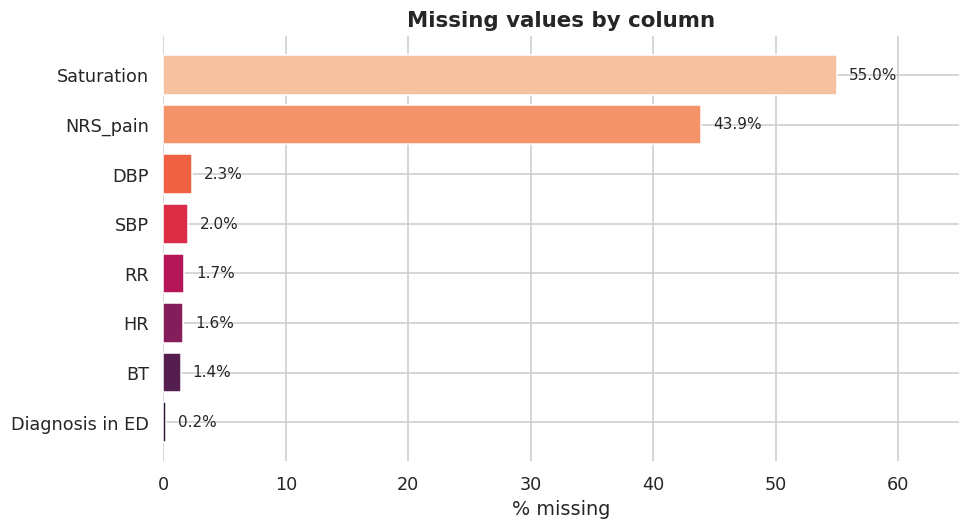

In [6]:
missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(1)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(missing_pct.index[::-1], missing_pct.values[::-1],
                color=sns.color_palette("rocket", len(missing_pct)))
for bar, val in zip(bars, missing_pct.values[::-1]):
    ax.text(val + 1, bar.get_y() + bar.get_height()/2, f"{val}%", va='center', fontsize=10)
ax.set_xlabel("% missing")
ax.set_title("Missing values by column", fontsize=14, fontweight='bold')
ax.set_xlim(0, max(missing_pct.values) + 10)
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

**`Saturation` (55%) and `NRS_pain` (44%) are heavily missing.** Before imputing them, it's worth checking *whether* a value is missing carries information — if sicker patients are less likely to have a pain score recorded (e.g. because they're unresponsive), the missingness pattern itself is a predictive signal, not just noise to fill in.

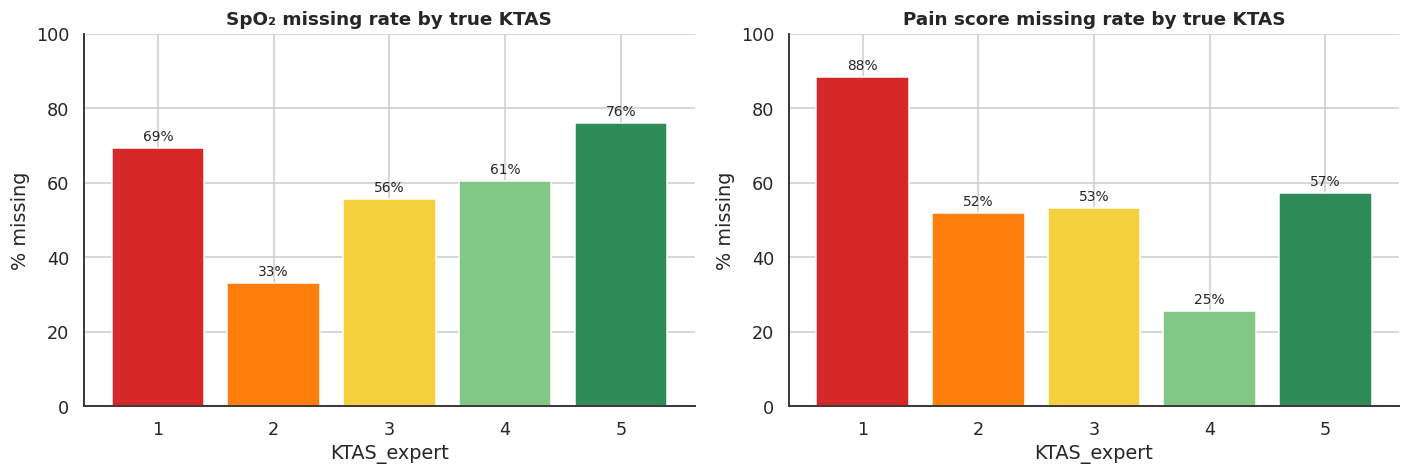

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for ax, col, title in zip(
    axes,
    ['Saturation', 'NRS_pain'],
    ['SpO₂ missing rate by true KTAS', 'Pain score missing rate by true KTAS']
):
    rates = df.groupby('KTAS_expert')[col].apply(lambda x: x.isna().mean() * 100)
    bars = ax.bar(rates.index.astype(str), rates.values, color=KTAS_COLORS)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel("KTAS_expert")
    ax.set_ylabel("% missing")
    ax.set_ylim(0, 100)
    for bar, val in zip(bars, rates.values):
        ax.text(bar.get_x()+bar.get_width()/2, val+2, f"{val:.0f}%", ha='center', fontsize=9)

sns.despine()
plt.tight_layout()
plt.show()

Missingness is clearly **not random** — it swings by 30-60 points across KTAS classes. We'll keep explicit `_missing` indicator flags as features later instead of quietly imputing them away.

## 5. Target variable: KTAS_expert

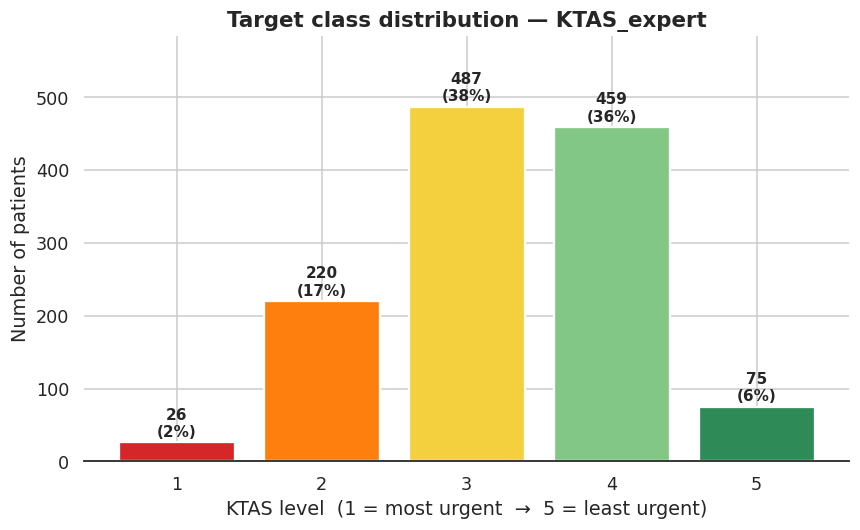

In [8]:
counts = df['KTAS_expert'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(counts.index.astype(str), counts.values, color=KTAS_COLORS, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x()+bar.get_width()/2, val+8, f"{val}\n({val/len(df)*100:.0f}%)",
            ha='center', fontsize=10, fontweight='bold')
ax.set_xlabel("KTAS level  (1 = most urgent  →  5 = least urgent)")
ax.set_ylabel("Number of patients")
ax.set_title("Target class distribution — KTAS_expert", fontsize=14, fontweight='bold')
ax.set_ylim(0, max(counts.values)*1.2)
sns.despine(left=True)
plt.tight_layout()
plt.show()

The classes are **heavily imbalanced**: KTAS 1 (most critical) is only 2% of patients, while KTAS 3–4 make up 75%. This has direct consequences for modeling — plain accuracy would be a misleading metric, and rare-but-critical class 1 needs explicit attention (e.g. class weighting) or the model will simply ignore it.

## 6. Feature distributions vs. KTAS

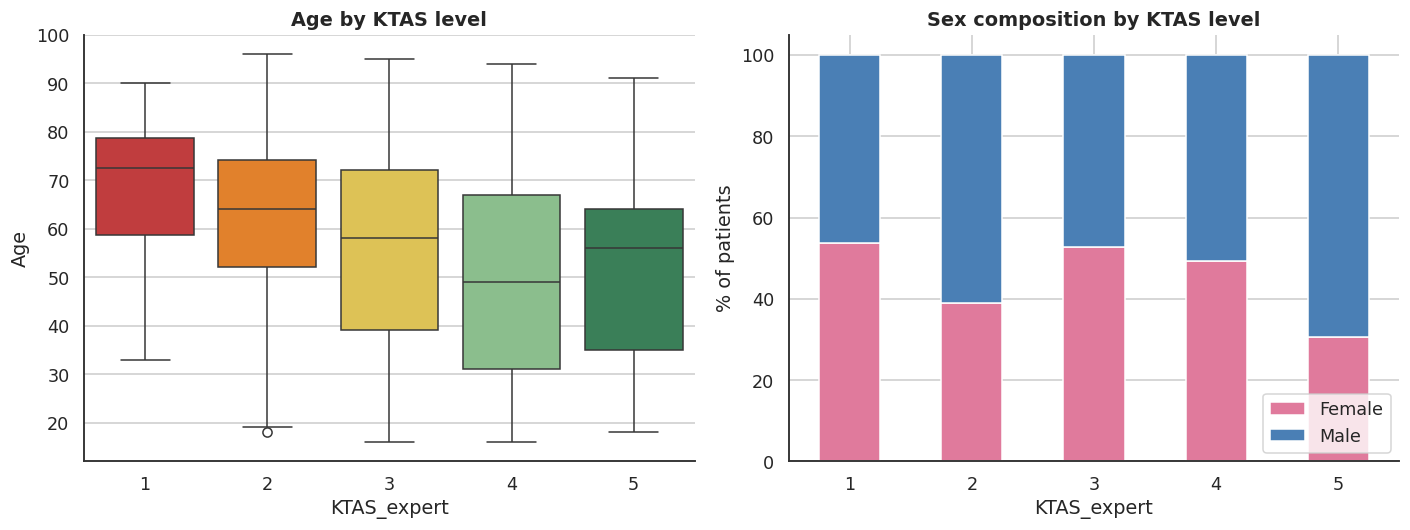

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(data=df, x='KTAS_expert', y='Age', hue='KTAS_expert',
            palette=KTAS_PALETTE, legend=False, ax=axes[0])
axes[0].set_title("Age by KTAS level", fontweight='bold')

sex_ktas = pd.crosstab(df['KTAS_expert'], df['Sex'].map({1: 'Female', 2: 'Male'}), normalize='index') * 100
sex_ktas.plot(kind='bar', stacked=True, ax=axes[1], color=['#e07a9c', '#4a7fb5'], edgecolor='white')
axes[1].set_title("Sex composition by KTAS level", fontweight='bold')
axes[1].set_ylabel("% of patients")
axes[1].legend(title=None, loc='lower right')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

sns.despine()
plt.tight_layout()
plt.show()

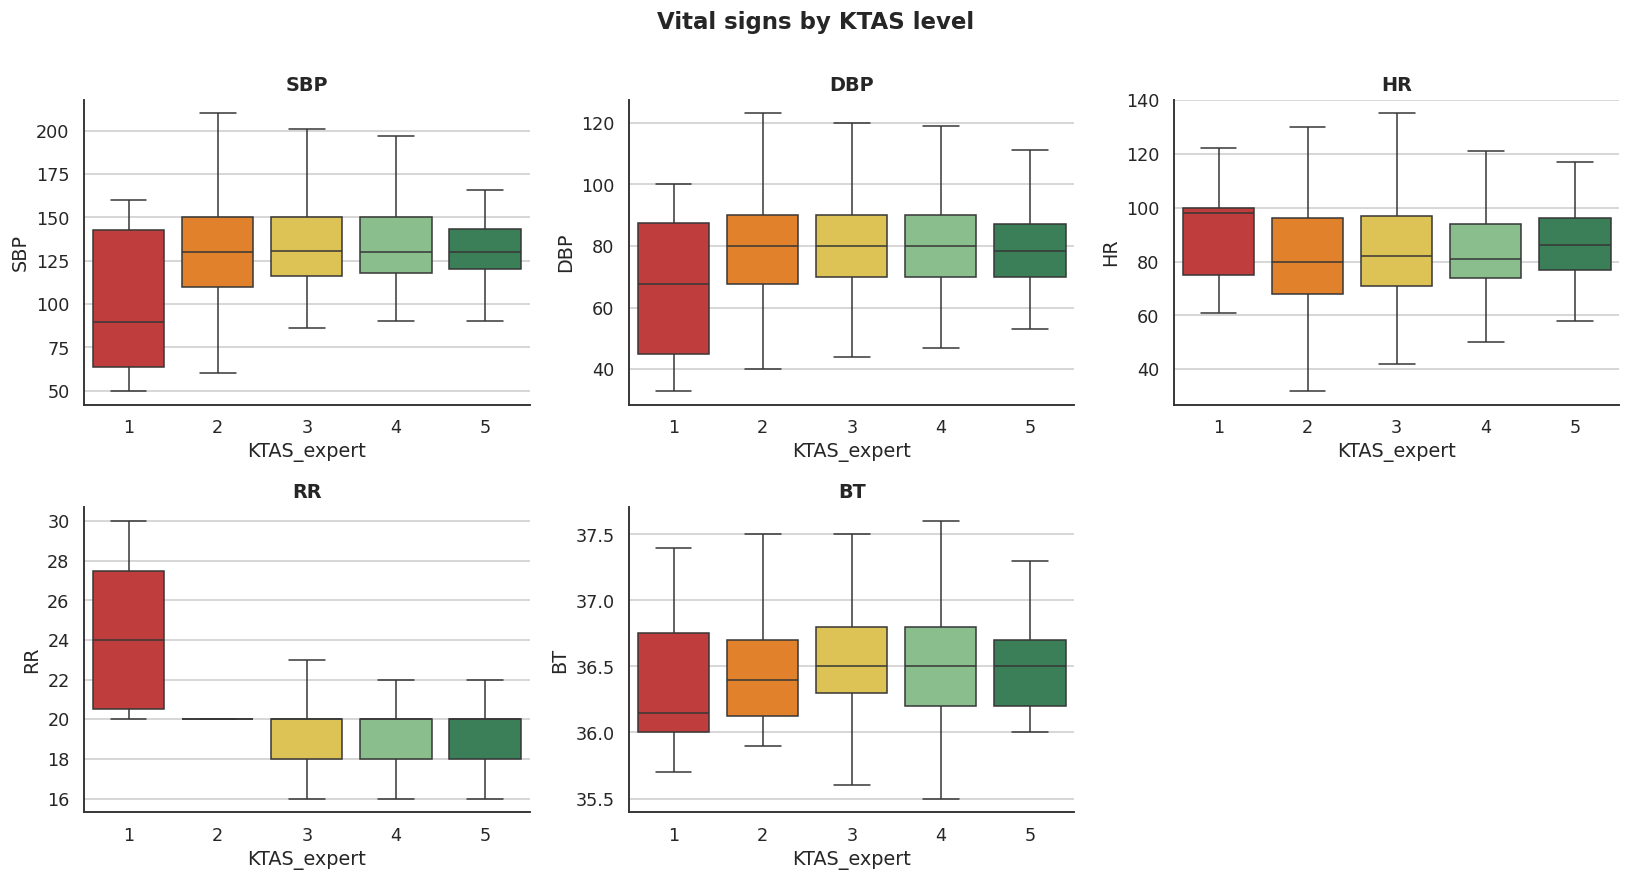

In [10]:
vitals = ['SBP', 'DBP', 'HR', 'RR', 'BT']
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, v in zip(axes, vitals):
    sns.boxplot(data=df, x='KTAS_expert', y=v, hue='KTAS_expert',
                palette=KTAS_PALETTE, legend=False, ax=ax, showfliers=False)
    ax.set_title(v, fontweight='bold')
    ax.set_xlabel("KTAS_expert")

axes[-1].axis('off')
fig.suptitle("Vital signs by KTAS level", fontsize=15, fontweight='bold', y=1.00)
sns.despine()
plt.tight_layout()
plt.show()

Individually, vitals overlap a lot across KTAS classes (real ED triage rarely hinges on one number) — respiratory rate and pain score show the clearest ordinal trend, which lines up with the correlation analysis below.

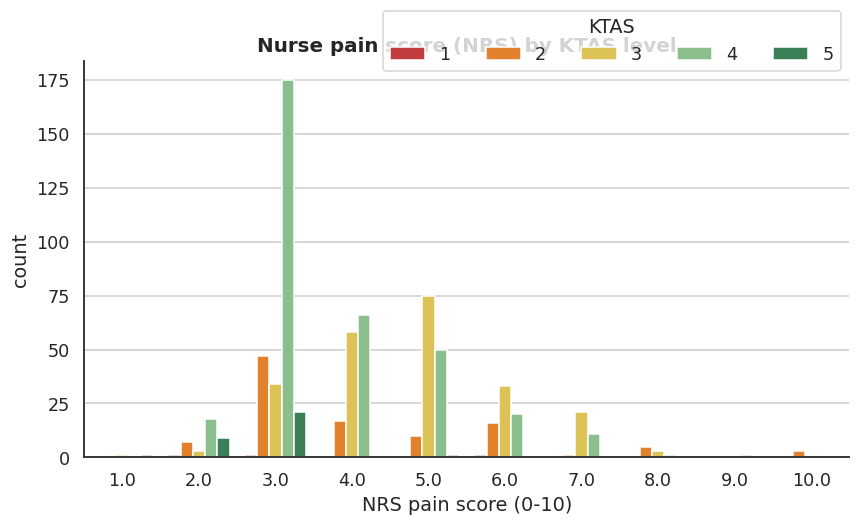

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.countplot(data=df, x='NRS_pain', hue='KTAS_expert', palette=KTAS_PALETTE, ax=ax)
ax.set_title("Nurse pain score (NRS) by KTAS level", fontsize=13, fontweight='bold')
ax.set_xlabel("NRS pain score (0-10)")
ax.legend(title="KTAS", loc='upper right', ncol=5, bbox_to_anchor=(1, 1.15))
sns.despine()
plt.tight_layout()
plt.show()

## 7. Correlation with target (Spearman — KTAS is ordinal)

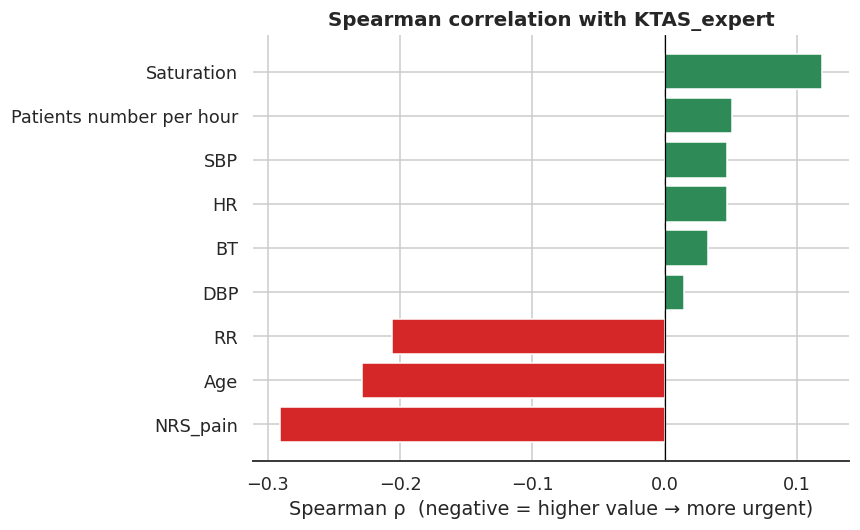

In [12]:
feats = ['Age', 'SBP', 'DBP', 'HR', 'RR', 'BT', 'Saturation', 'NRS_pain', 'Patients number per hour']
rhos = {}
for f in feats:
    mask = df[f].notna()
    rho, p = spearmanr(df.loc[mask, f], df.loc[mask, 'KTAS_expert'])
    rhos[f] = rho

rho_series = pd.Series(rhos).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#d62728' if v < 0 else '#2e8b57' for v in rho_series.values]
ax.barh(rho_series.index, rho_series.values, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title("Spearman correlation with KTAS_expert", fontsize=13, fontweight='bold')
ax.set_xlabel("Spearman ρ  (negative = higher value → more urgent)")
sns.despine(left=True)
plt.tight_layout()
plt.show()

`NRS_pain`, `Age`, and `RR` show the strongest ordinal relationships with acuity. No single vital sign is a strong predictor on its own — this is expected clinically and is why a tree-based model that can capture interactions (e.g. \"high RR *and* altered mental state\") should outperform any single threshold rule.

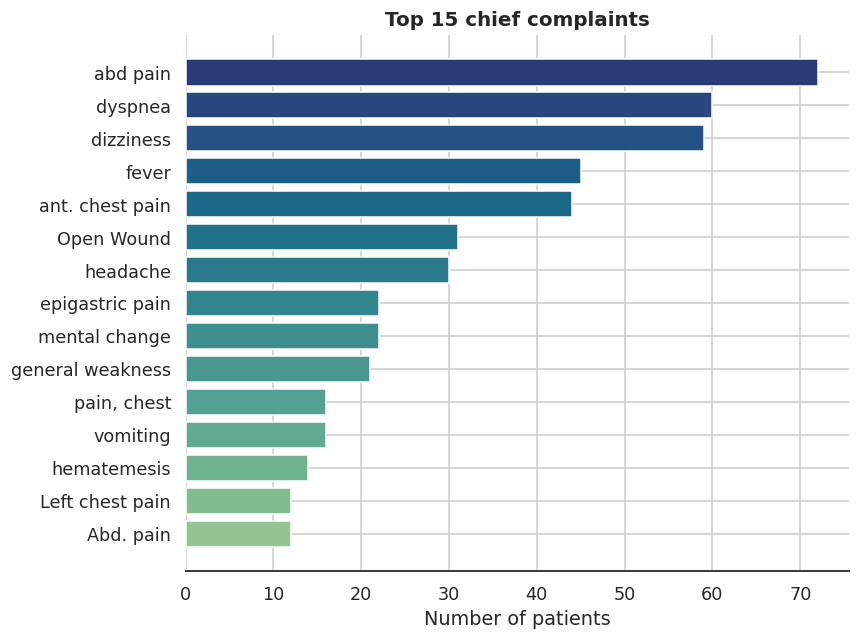

Total unique chief complaints: 417 (out of 1267 patients)


In [13]:
top_complaints = df['Chief_complain'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top_complaints.index[::-1], top_complaints.values[::-1], color=sns.color_palette("crest", 15))
ax.set_title("Top 15 chief complaints", fontsize=13, fontweight='bold')
ax.set_xlabel("Number of patients")
sns.despine(left=True)
plt.tight_layout()
plt.show()

print(f"Total unique chief complaints: {df['Chief_complain'].nunique()} (out of {len(df)} patients)")

## 8. ⚠️ Data-leakage audit

As flagged in the column reference above, several columns are only known **after** the ED visit is over. The cell below shows *why* this matters: `KTAS_RN` (the nurse's own real-time guess) alone predicts `KTAS_expert` almost perfectly. Training on it would inflate every metric below to a level that looks great in a notebook but would be **impossible to reproduce in a live application**, since a nurse entering a new patient won't have this information yet.

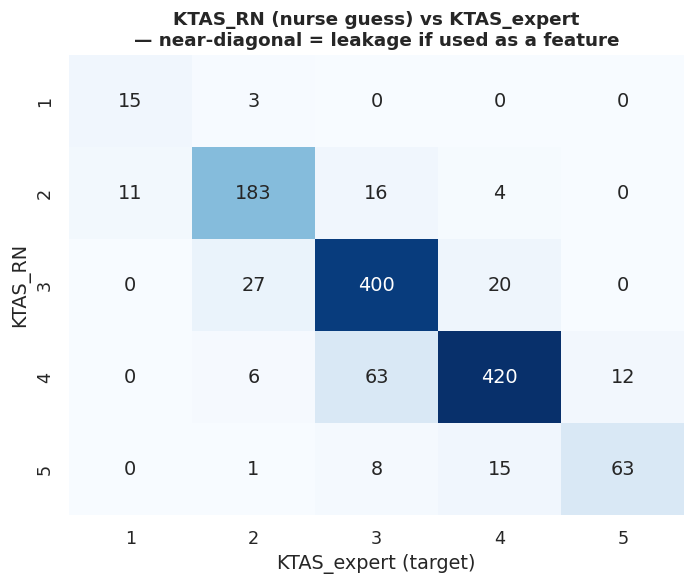


Dropped 7 leakage columns. Remaining: 17 columns.


In [14]:
crosstab = pd.crosstab(df['KTAS_RN'], df['KTAS_expert'])

fig, ax = plt.subplots(figsize=(6.5, 5.5))
sns.heatmap(crosstab, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax)
ax.set_title("KTAS_RN (nurse guess) vs KTAS_expert\n— near-diagonal = leakage if used as a feature",
             fontsize=12, fontweight='bold')
ax.set_xlabel("KTAS_expert (target)")
ax.set_ylabel("KTAS_RN")
plt.tight_layout()
plt.show()

LEAKAGE_COLS = ['KTAS_RN', 'Diagnosis in ED', 'Disposition', 'Error_group',
                'Length of stay_min', 'KTAS duration_min', 'mistriage']
df_model = df.drop(columns=LEAKAGE_COLS)
print(f"\nDropped {len(LEAKAGE_COLS)} leakage columns. Remaining: {df_model.shape[1]} columns.")

## 9. Feature engineering

- Add `_missing` indicator flags for vitals with informative missingness (Section 4).
- Group the 417 raw `Chief_complain` free-text values into the ~27 most frequent complaints + "other" — high-cardinality raw text would otherwise overfit badly on only ~1000 training rows.
- Cast true categorical columns to pandas `category` dtype so XGBoost and LightGBM can split on them natively (CatBoost gets its own string-encoded copy later).

In [15]:
for c in ['Saturation', 'NRS_pain', 'SBP', 'DBP', 'HR', 'RR', 'BT']:
    df_model[c + '_missing'] = df_model[c].isna().astype(int)

top_complaints = df_model['Chief_complain'].value_counts()
keep = set(top_complaints[top_complaints >= 8].index)
df_model['Chief_complain_grp'] = df_model['Chief_complain'].where(
    df_model['Chief_complain'].isin(keep), 'other'
)
print(f"Chief_complain: {df_model['Chief_complain'].nunique()} raw -> "
      f"{df_model['Chief_complain_grp'].nunique()} grouped categories")

cat_cols = ['Sex', 'Arrival mode', 'Injury', 'Mental', 'Pain', 'Group', 'Chief_complain_grp']
for c in cat_cols:
    df_model[c] = df_model[c].astype('category')

num_cols = ['Age', 'NRS_pain', 'SBP', 'DBP', 'HR', 'RR', 'BT', 'Saturation', 'Patients number per hour']
miss_ind_cols = [c + '_missing' for c in ['Saturation', 'NRS_pain', 'SBP', 'DBP', 'HR', 'RR', 'BT']]

feature_cols = cat_cols + num_cols + miss_ind_cols
X = df_model[feature_cols]
y = df_model['KTAS_expert'] - 1   # 0..4 for the models

print(f"\nFinal feature matrix: {X.shape}")

Chief_complain: 417 raw -> 27 grouped categories

Final feature matrix: (1267, 23)


## 10. Train / test split & class weighting

In [16]:
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import f1_score, cohen_kappa_score, classification_report, confusion_matrix

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

class_counts = y_train.value_counts().sort_index()
n = len(y_train)
weights_map = np.sqrt(n / (5 * class_counts)).to_dict()   # sqrt-inverse frequency: balances rare classes without overcorrecting
sample_weight = y_train.map(weights_map).values
print("\nClass weights (sqrt-inverse frequency):")
print(pd.Series(weights_map).sort_index())

Train: (1013, 23), Test: (254, 23)

Class weights (sqrt-inverse frequency):
0    3.106062
1    1.072910
2    0.721680
3    0.742996
4    1.837571
dtype: float64


## 11. Model 1 — XGBoost

`RandomizedSearchCV` with 5-fold stratified CV, optimizing macro-F1 (treats all 5 classes as equally important, so the rare-but-critical classes aren't ignored).

In [17]:
import xgboost as xgb

xgb_base = xgb.XGBClassifier(
    objective='multi:softprob', num_class=5, enable_categorical=True,
    tree_method='hist', eval_metric='mlogloss', random_state=RANDOM_STATE,
)

xgb_param_dist = {
    'n_estimators': [200, 300, 400, 600, 800],
    'max_depth': [3, 4, 5, 6, 8],
    'learning_rate': [0.01, 0.02, 0.05, 0.08, 0.1],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5, 7],
    'gamma': [0, 0.1, 0.3, 0.5],
    'reg_alpha': [0, 0.1, 0.5, 1.0],
    'reg_lambda': [0.5, 1.0, 1.5, 2.0],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
xgb_search = RandomizedSearchCV(
    xgb_base, xgb_param_dist, n_iter=40, scoring='f1_macro',
    cv=cv, random_state=RANDOM_STATE, n_jobs=-1, verbose=0
)
xgb_search.fit(X_train, y_train, sample_weight=sample_weight)

print("Best CV macro-F1 (XGBoost):", round(xgb_search.best_score_, 4))
print("Best params:", xgb_search.best_params_)

xgb_model = xgb_search.best_estimator_

Best CV macro-F1 (XGBoost): 0.5749
Best params: {'subsample': 0.9, 'reg_lambda': 0.5, 'reg_alpha': 1.0, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.02, 'gamma': 0, 'colsample_bytree': 1.0}


## 12. Model 2 — CatBoost

CatBoost handles categorical features natively via its own target-statistic encoding, so categorical columns are passed as plain strings (with missing values labeled explicitly) rather than one-hot or pandas `category` codes. Its sklearn wrapper isn't fully `clone()`-compatible when `cat_features` is set in the constructor, so tuning uses a small manual random search instead of `RandomizedSearchCV`.

In [18]:
from catboost import CatBoostClassifier
import random

def to_catboost_frame(X):
    X = X.copy()
    for c in cat_cols:
        X[c] = X[c].astype(str).replace('nan', 'missing')
    return X

X_train_cb = to_catboost_frame(X_train)
X_test_cb = to_catboost_frame(X_test)
cat_idx = [X_train_cb.columns.get_loc(c) for c in cat_cols]

cb_param_grid = {
    'iterations': [150, 250, 350, 500],
    'depth': [3, 4, 5, 6, 8],
    'learning_rate': [0.01, 0.02, 0.05, 0.08, 0.1],
    'l2_leaf_reg': [1, 3, 5, 7, 9],
    'border_count': [32, 64, 128],
    'bagging_temperature': [0, 0.5, 1.0],
}

random.seed(RANDOM_STATE)
cb_best_score, cb_best_params = -1, None

for i in range(15):
    params = {k: random.choice(v) for k, v in cb_param_grid.items()}
    fold_scores = []
    for tr_idx, val_idx in cv.split(X_train_cb, y_train):
        m = CatBoostClassifier(loss_function='MultiClass', cat_features=cat_idx,
                                random_seed=RANDOM_STATE, verbose=False,
                                allow_writing_files=False, **params)
        m.fit(X_train_cb.iloc[tr_idx], y_train.iloc[tr_idx], sample_weight=sample_weight[tr_idx])
        pred = m.predict(X_train_cb.iloc[val_idx]).flatten()
        fold_scores.append(f1_score(y_train.iloc[val_idx], pred, average='macro'))
    mean_score = np.mean(fold_scores)
    if mean_score > cb_best_score:
        cb_best_score, cb_best_params = mean_score, params

print("Best CV macro-F1 (CatBoost):", round(cb_best_score, 4))
print("Best params:", cb_best_params)

cb_model = CatBoostClassifier(loss_function='MultiClass', cat_features=cat_idx,
                               random_seed=RANDOM_STATE, verbose=False,
                               allow_writing_files=False, **cb_best_params)
cb_model.fit(X_train_cb, y_train, sample_weight=sample_weight)

Best CV macro-F1 (CatBoost): 0.5578
Best params: {'iterations': 150, 'depth': 3, 'learning_rate': 0.05, 'l2_leaf_reg': 3, 'border_count': 32, 'bagging_temperature': 0}


CatBoostClassifier(allow_writing_files=False, bagging_temperature=0, border_count=32, cat_features=[0, 1, 2, 3, 4, 5, 6], depth=3, iterations=150, l2_leaf_reg=3, learning_rate=0.05, loss_function='MultiClass', random_seed=42, verbose=False)

## 13. Model 3 — LightGBM

LightGBM's sklearn wrapper auto-detects pandas `category` dtype columns, so it can reuse the exact same `X_train`/`X_test` as XGBoost.

In [19]:
from lightgbm import LGBMClassifier

lgb_base = LGBMClassifier(objective='multiclass', num_class=5, random_state=RANDOM_STATE, verbosity=-1)

lgb_param_dist = {
    'n_estimators': [200, 300, 400, 600, 800],
    'num_leaves': [15, 31, 63, 127],
    'max_depth': [-1, 4, 6, 8],
    'learning_rate': [0.01, 0.02, 0.05, 0.08, 0.1],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'min_child_samples': [5, 10, 20, 30],
    'reg_alpha': [0, 0.1, 0.5, 1.0],
    'reg_lambda': [0.5, 1.0, 1.5, 2.0],
}

lgb_search = RandomizedSearchCV(
    lgb_base, lgb_param_dist, n_iter=40, scoring='f1_macro',
    cv=cv, random_state=RANDOM_STATE, n_jobs=-1, verbose=0
)
lgb_search.fit(X_train, y_train, sample_weight=sample_weight)

print("Best CV macro-F1 (LightGBM):", round(lgb_search.best_score_, 4))
print("Best params:", lgb_search.best_params_)

lgb_model = lgb_search.best_estimator_

Best CV macro-F1 (LightGBM): 0.5445
Best params: {'subsample': 0.6, 'reg_lambda': 1.5, 'reg_alpha': 1.0, 'num_leaves': 31, 'n_estimators': 800, 'min_child_samples': 10, 'max_depth': 4, 'learning_rate': 0.01, 'colsample_bytree': 1.0}


## 14. Cost-sensitive triage threshold

Not all mistakes are equal in a triage tool: predicting a patient as **less urgent** than they truly are is dangerous (under-triage); predicting **more urgent** than needed just costs a bit of extra caution (over-triage). Instead of always picking a model's single most-likely class, we compute the *expected cost* of each possible prediction — penalizing under-triage errors 1.5× — and pick the lowest-cost class. This is applied identically to all three models below for a fair comparison.

In [20]:
K = 5
UNDER_COST = 1.5

def cost_sensitive_predict(proba, under_cost=UNDER_COST, over_cost=1.0):
    cost_matrix = np.zeros((K, K))
    for t in range(K):
        for p in range(K):
            if p > t:
                cost_matrix[t, p] = (p - t) * under_cost
            elif p < t:
                cost_matrix[t, p] = (t - p) * over_cost
    return (proba @ cost_matrix).argmin(axis=1)

def evaluate(y_true, pred, name):
    macro_f1 = f1_score(y_true, pred, average='macro')
    kappa = cohen_kappa_score(y_true, pred, weights='quadratic')
    diff = pred - y_true.values
    exact = (diff == 0).mean()
    under = (diff > 0).mean()
    over = (diff < 0).mean()
    severe_mask = (y_true == 0) | (y_true == 1)
    severe_recall = (pred[severe_mask.values] <= 1).mean()
    return dict(model=name, macro_f1=macro_f1, kappa=kappa, exact=exact,
                under_triage=under, over_triage=over, severe_recall=severe_recall)

proba_xgb = xgb_model.predict_proba(X_test)
proba_cb = cb_model.predict_proba(X_test_cb)
proba_lgb = lgb_model.predict_proba(X_test)

results = []
preds_raw, preds_cs, cms = {}, {}, {}
for name, proba in [('XGBoost', proba_xgb), ('CatBoost', proba_cb), ('LightGBM', proba_lgb)]:
    pred_raw = proba.argmax(axis=1)
    pred_cs = cost_sensitive_predict(proba)
    preds_raw[name] = pred_raw
    preds_cs[name] = pred_cs
    results.append(evaluate(y_test, pred_raw, f"{name} (raw)"))
    results.append(evaluate(y_test, pred_cs, f"{name} (cost-sensitive)"))
    cms[name] = confusion_matrix(y_test + 1, pred_cs + 1)

results_df = pd.DataFrame(results).set_index('model').round(3)
results_df

,macro_f1,kappa,exact,under_triage,over_triage,severe_recall
model,,,,,,
XGBoost (raw),0.530,0.509,0.654,0.189,0.157,0.653
XGBoost (cost-sensitive),0.529,0.578,0.697,0.102,0.201,0.653
CatBoost (raw),0.668,0.604,0.693,0.181,0.126,0.673
CatBoost (cost-sensitive),0.572,0.578,0.654,0.110,0.236,0.612
LightGBM (raw),0.541,0.497,0.642,0.197,0.161,0.633
LightGBM (cost-sensitive),0.557,0.532,0.677,0.118,0.205,0.653


## 15. Model comparison

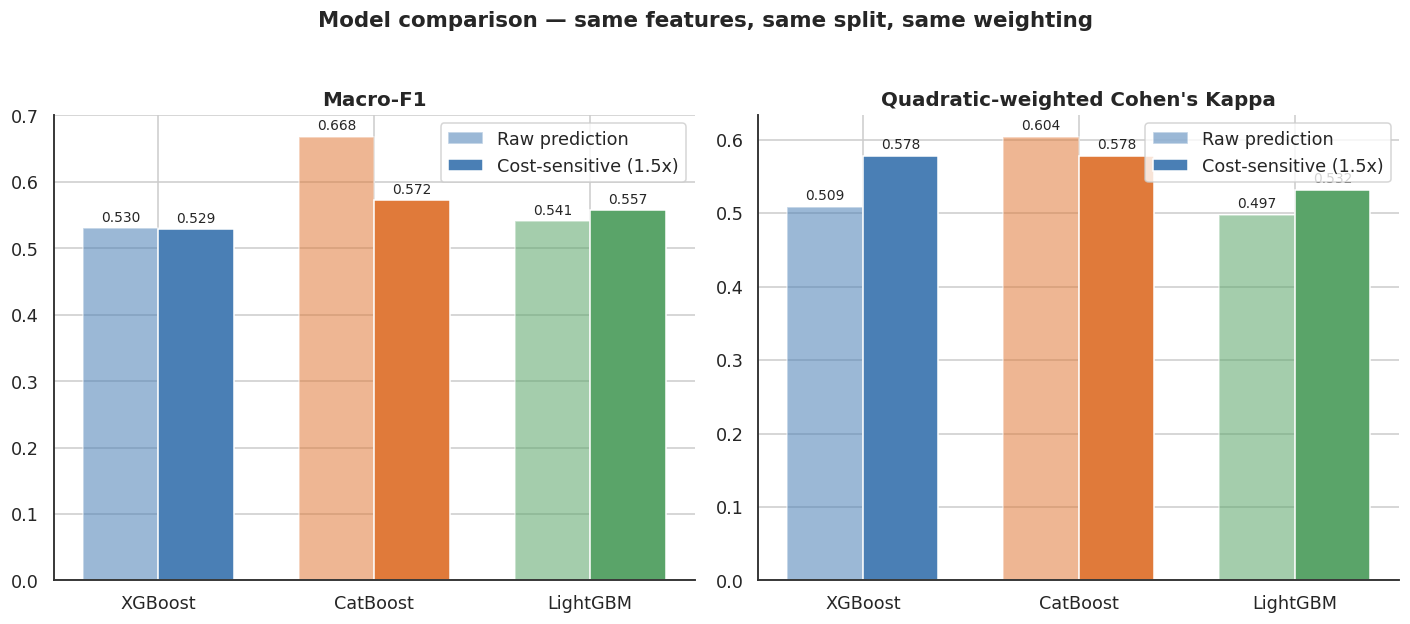

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
model_names = ['XGBoost', 'CatBoost', 'LightGBM']
colors = ['#4a7fb5', '#e07a3a', '#5aa469']

for ax, metric, title in zip(axes, ['macro_f1', 'kappa'],
                              ['Macro-F1', "Quadratic-weighted Cohen's Kappa"]):
    raw_vals = [results_df.loc[f'{m} (raw)', metric] for m in model_names]
    cs_vals = [results_df.loc[f'{m} (cost-sensitive)', metric] for m in model_names]
    x = np.arange(len(model_names))
    width = 0.35
    ax.bar(x - width/2, raw_vals, width, label='Raw prediction', color=colors, alpha=0.55)
    ax.bar(x + width/2, cs_vals, width, label='Cost-sensitive (1.5x)', color=colors)
    ax.set_xticks(x)
    ax.set_xticklabels(model_names)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.legend()
    for xi, v in zip(x - width/2, raw_vals):
        ax.text(xi, v + 0.01, f"{v:.3f}", ha='center', fontsize=9)
    for xi, v in zip(x + width/2, cs_vals):
        ax.text(xi, v + 0.01, f"{v:.3f}", ha='center', fontsize=9)

fig.suptitle("Model comparison — same features, same split, same weighting", fontsize=14, fontweight='bold', y=1.03)
sns.despine()
plt.tight_layout()
plt.show()

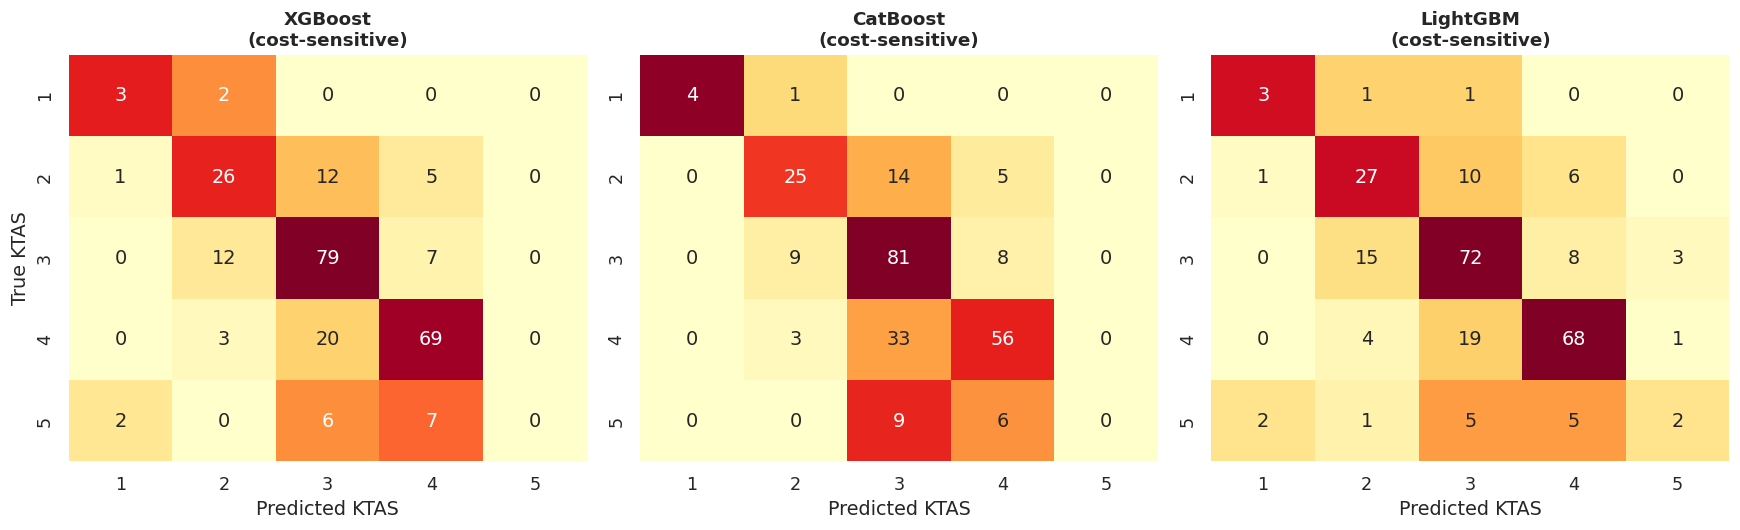

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, name in zip(axes, model_names):
    cm = cms[name]
    cm_pct = cm / cm.sum(axis=1, keepdims=True) * 100
    sns.heatmap(cm_pct, annot=cm, fmt='d', cmap='YlOrRd', cbar=False,
                xticklabels=range(1, 6), yticklabels=range(1, 6), ax=ax)
    ax.set_title(f"{name}\n(cost-sensitive)", fontsize=12, fontweight='bold')
    ax.set_xlabel("Predicted KTAS")
    ax.set_ylabel("True KTAS" if name == 'XGBoost' else "")

plt.tight_layout()
plt.show()

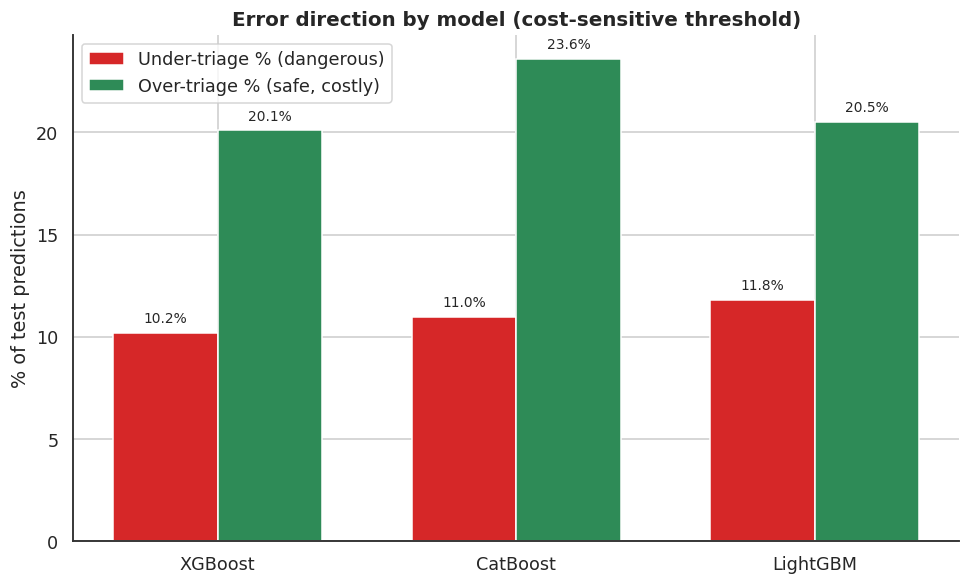

In [23]:
fig, ax = plt.subplots(figsize=(9, 5.5))
width = 0.35
x = np.arange(len(model_names))
under_vals = [results_df.loc[f'{m} (cost-sensitive)', 'under_triage'] * 100 for m in model_names]
over_vals = [results_df.loc[f'{m} (cost-sensitive)', 'over_triage'] * 100 for m in model_names]

ax.bar(x - width/2, under_vals, width, label='Under-triage % (dangerous)', color='#d62728')
ax.bar(x + width/2, over_vals, width, label='Over-triage % (safe, costly)', color='#2e8b57')
ax.set_xticks(x)
ax.set_xticklabels(model_names)
ax.set_ylabel("% of test predictions")
ax.set_title("Error direction by model (cost-sensitive threshold)", fontsize=13, fontweight='bold')
ax.legend()
for xi, v in zip(x - width/2, under_vals):
    ax.text(xi, v + 0.5, f"{v:.1f}%", ha='center', fontsize=9)
for xi, v in zip(x + width/2, over_vals):
    ax.text(xi, v + 0.5, f"{v:.1f}%", ha='center', fontsize=9)
sns.despine()
plt.tight_layout()
plt.show()

In [24]:
best_model_name = results_df.loc[[f'{m} (cost-sensitive)' for m in model_names], 'kappa'].idxmax()
print(f"Best model on held-out test set (cost-sensitive, quadratic kappa): {best_model_name}")
results_df.sort_values('kappa', ascending=False)

Best model on held-out test set (cost-sensitive, quadratic kappa): XGBoost (cost-sensitive)


,macro_f1,kappa,exact,under_triage,over_triage,severe_recall
model,,,,,,
CatBoost (raw),0.668,0.604,0.693,0.181,0.126,0.673
XGBoost (cost-sensitive),0.529,0.578,0.697,0.102,0.201,0.653
CatBoost (cost-sensitive),0.572,0.578,0.654,0.110,0.236,0.612
LightGBM (cost-sensitive),0.557,0.532,0.677,0.118,0.205,0.653
XGBoost (raw),0.530,0.509,0.654,0.189,0.157,0.653
LightGBM (raw),0.541,0.497,0.642,0.197,0.161,0.633


## 16. Conclusions & limitations

- **CatBoost was the strongest of the three gradient boosting libraries** on this dataset, both in raw prediction and after the cost-sensitive safety adjustment — likely because this feature set leans heavily on categorical variables (`Chief_complain` groups, `Mental`, `Arrival mode`) with only ~1000 training rows, a setting where CatBoost's ordered target-statistic encoding tends to out-perform one-hot/native categorical splits.
- All three models were evaluated **only on information available at the moment of triage** — a realistic, deployable comparison, not one inflated by post-visit leakage (Section 8).
- The strongest individual signals across models are respiratory rate, whether vitals were even recorded (a proxy for how critical the patient was), mental status, chief complaint, and pain score — consistent with how KTAS is defined clinically.
- The cost-sensitive threshold is a **tunable dial**, not a fixed choice: a hospital could set the under-triage penalty higher (fewer missed critical patients, more false alarms) or lower depending on their protocol.
- **Caveats:** 1267 rows is a small dataset for 5-class prediction across three models; the "missing vitals → critical patient" signal is powerful but based on very few examples; class 5 (least urgent) is the hardest class to separate from class 3–4 for every model tested and would benefit most from more data.
